# 02 – Limpeza e Preparação dos Dados (Data Cleaning & Preparation)

## 🎯 Objetivo
Este notebook tem como objetivo aplicar, de forma sistemática, as regras de limpeza e preparação dos dados definidas a partir do diagnóstico de qualidade realizado na etapa anterior. O foco é transformar a base bruta de vendas em um conjunto de dados **consistente, confiável e pronto para análise de negócio**.

## 🧩 Contexto
Na etapa de diagnóstico (`01_diagnostico_qualidade.ipynb`), foram identificados problemas relevantes de qualidade dos dados, incluindo:
- Inconsistências no cálculo do faturamento em relação à regra de negócio (Preço Unitário × Quantidade × (1 – Desconto));
- Presença de registros duplicados;
- Identificadores de venda não únicos, exigindo definição de uma chave técnica;
- Campos categóricos com valores ausentes ou padronização inconsistente (localidade, categoria e forma de pagamento).

Essas inconsistências inviabilizam análises confiáveis e podem distorcer KPIs operacionais e financeiros.

## 🛠️ Abordagem
Neste notebook, são implementadas as seguintes etapas:
- Padronização de nomes de colunas e tipagem correta das variáveis;
- Tratamento de outliers operacionais e validação de regras de negócio para variáveis críticas;
- Definição de uma chave técnica para representar a granularidade correta dos registros;
- Diagnóstico e resolução de registros duplicados;
- Cálculo do faturamento esperado com base na regra de negócio, mantendo o valor informado para fins de auditoria e análise de impacto;
- Padronização de campos categóricos (localidade, categoria e forma de pagamento);
- Tratamento de valores ausentes conforme regras acordadas;
- Geração de uma base final limpa e versionada para as etapas analíticas subsequentes.

## 📦 Entregável
Ao final deste processo, é gerada uma base de dados tratada e armazenada na pasta `data/processed/`, que servirá como insumo para:
- Análises exploratórias (EDA);
- Cálculo de KPIs;
- Geração de insights de negócio e possíveis modelos analíticos futuros.

> **Observação:** Todas as decisões de tratamento adotadas aqui são documentadas ao longo do notebook, garantindo rastreabilidade e reprodutibilidade do pipeline de preparação dos dados.
---

# 1. Carregamento da Base de Dados

Nesta etapa, a base de dados bruta é carregada a partir do diretório de dados originais (`data/raw`) e copiada para um dataframe de trabalho. A base original é mantida inalterada ao longo de todo o processo, assegurando rastreabilidade, auditoria e reprodutibilidade do pipeline de preparação dos dados.

## 1.1. Configuração do Ambiente

Nesta seção são importadas as bibliotecas utilizadas ao longo do notebook para manipulação, diagnóstico inicial e visualização de dados. Essa configuração padroniza o ambiente de execução e garante a reprodutibilidade das etapas de preparação dos dados.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df_raw= pd.read_csv("../data/raw/vendas_loja_crm_sujo.csv")

# Criar cópia de trabalho
df = df_raw.copy()

print(f"Tamanho da base original (linhas, colunas): {df_raw.shape}")
display(df.head())

Tamanho da base original (linhas, colunas): (12000, 10)


,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento
0,2127,2023-10-02 10:11:55.677118076,Camisa D,Roupas,80,1,0.16,94.08,Rio de Janeiro,Pix
1,2460,2024-01-04 06:53:04.523015344,Fone C,Eletrônicos,300,1,0.01,415.80,SP,Cartão de Crédito
2,1861,2023-08-09 19:58:52.755170112,Camisa D,NaN,"R$ 80,00",2,0.07,148.80,São Paulo,Cartão de Débito
3,2295,2023-10-21 05:17:00.680453636,Camisa D,Roupas,80,3,0.05,319.20,Belo Horizonte,Cartão de Crédito
4,2131,2023-10-09 00:00:00.000000000,Notebook B,Eletrônicos,3500,3,0.03,14259.00,Curitiba,Cartão de Crédito


---
# 2. Estrutura dos Dados

Antes de iniciar qualquer etapa de tratamento, é realizada uma inspeção da estrutura da base de dados (colunas, tipos de dados, cardinalidade e presença de valores ausentes), utilizando métricas descritivas e metadados do dataframe.

In [3]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID da Venda         12000 non-null  int64  
 1   Data da Venda       12000 non-null  str    
 2   Produto             12000 non-null  str    
 3   Categoria           11519 non-null  str    
 4   Preço Unitário      12000 non-null  str    
 5   Quantidade Vendida  12000 non-null  int64  
 6   Desconto            12000 non-null  float64
 7   Valor Total         12000 non-null  float64
 8   Localização         11533 non-null  str    
 9   Forma de Pagamento  11517 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 937.6 KB


,ID da Venda,Data da Venda,Produto,Categoria,Preço Unitário,Quantidade Vendida,Desconto,Valor Total,Localização,Forma de Pagamento
count,12000.000000,12000,12000,11519,12000,12000.000000,12000.000000,12000.000000,11533,11517
unique,NaN,10955,8,4,16,NaN,NaN,NaN,12,4
top,NaN,2023-09-11 00:00:00.000000000,Smartphone A,Roupas,1200,NaN,NaN,NaN,São Paulo,Cartão de Crédito
freq,NaN,8,1594,4356,1479,NaN,NaN,NaN,2830,5306
mean,1757.156667,NaN,NaN,NaN,NaN,4.120583,0.067605,2444.549189,NaN,NaN
std,429.375313,NaN,NaN,NaN,NaN,12.668784,0.070671,4280.117970,NaN,NaN
min,1001.000000,NaN,NaN,NaN,NaN,1.000000,0.000000,43.144094,NaN,NaN
25%,1389.750000,NaN,NaN,NaN,NaN,2.000000,0.030000,291.000000,NaN,NaN
50%,1763.000000,NaN,NaN,NaN,NaN,3.000000,0.060000,720.000000,NaN,NaN
75%,2127.000000,NaN,NaN,NaN,NaN,4.000000,0.090000,2376.000000,NaN,NaN


---
# 3. Análise e Limpeza das Colunas
Nesta seção, cada coluna relevante da base é analisada individualmente quanto à tipagem, domínio de valores e coerência com as regras de negócio. As decisões de tratamento são documentadas ao longo do processo, priorizando consistência analítica e rastreabilidade das transformações aplicadas.

## 3.1. Renomeando as colunas
Nesta etapa, os nomes das colunas são padronizados para um formato consistente (snake_case), facilitando a leitura, a manutenção do código e a integração com pipelines analíticos e scripts em Python. Essa padronização reduz a probabilidade de erros e melhora a legibilidade das transformações subsequentes.

In [4]:
col_map = {
    "ID da Venda": "id_venda",
    "Data da Venda": "data_venda",
    "Produto": "produto",
    "Categoria": "categoria",
    "Preço Unitário": "preco_unitario",
    "Quantidade Vendida": "quantidade_vendida",
    "Desconto": "desconto",
    "Valor Total": "valor_total",
    "Localização": "localizacao",
    "Forma de Pagamento": "forma_pagamento"
}

df = df.rename(columns=col_map)

> As colunas foram renomeadas para adotar um padrão consistente de nomenclatura (snake_case), reduzindo a probabilidade de erros de digitação no código e facilitando a manutenção e a reprodutibilidade do pipeline analítico em Python.

## 3.2. Conversão e Validação da Coluna `data_venda`
Nesta etapa, a coluna `data_venda` é convertida para o tipo datetime, permitindo análises temporais consistentes e evitando interpretações incorretas de formato. Também é realizada uma validação básica para identificar possíveis valores inválidos ou ausentes.

In [5]:
df["data_venda"] = pd.to_datetime(df["data_venda"], errors="coerce")
df["data_venda"].info()

<class 'pandas.Series'>
RangeIndex: 12000 entries, 0 to 11999
Series name: data_venda
Non-Null Count  Dtype         
--------------  -----         
12000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 93.9 KB


In [6]:
df["data_venda"].describe()

count                            12000
mean     2023-07-03 02:39:54.655636992
min      2022-12-03 05:49:40.386924616
25%      2023-04-05 05:56:38.265510144
50%      2023-07-04 02:34:10.967311616
75%      2023-09-30 18:48:45.150099968
max                2024-06-01 00:00:00
Name: data_venda, dtype: object

> A coluna `data_venda` foi convertida para o tipo `datetime`, permitindo a realização de análises temporais consistentes (tendências ao longo do tempo, sazonalidade e agregações por período).

## 3.3. Conversão, Normalização e Validação da Coluna `preco_unitario`
Nesta etapa, a coluna `preco_unitario` é convertida para formato numérico, com normalização de separadores decimais e remoção de símbolos monetários. Adicionalmente, é realizada uma validação de consistência semântica entre produto e preço unitário, verificando se cada produto apresenta um valor único ao longo da base.

In [7]:
df["preco_unitario"] = (
    df["preco_unitario"]
    .astype(str)
    .str.replace("R$", "", regex=False)
    .str.replace(" ", "", regex=False)
    .str.replace(".", "", regex=False)   # remove separador de milhar
    .str.replace(",", ".", regex=False)  # vírgula decimal → ponto
    .str.strip()
)

df["preco_unitario"] = pd.to_numeric(df["preco_unitario"], errors="coerce")

In [8]:
df["preco_unitario"].describe()

count    12000.000000
mean       754.852500
std       1090.433675
min         60.000000
25%        120.000000
50%        300.000000
75%       1200.000000
max       3500.000000
Name: preco_unitario, dtype: float64

In [9]:
df["preco_unitario"].isna().mean()

np.float64(0.0)

> Após a conversão, os valores de `preco_unitario` foram validados quanto ao domínio e à presença de valores ausentes.

### 3.3.1. Validação de Consistência entre `produto` e `preco_unitario`
Nesta etapa, é avaliado se cada produto apresenta um único valor de `preco_unitario` ao longo da base, validando a consistência semântica do cadastro de produtos e identificando possíveis divergências de preço que poderiam indicar erros de registro.

In [10]:
# Número de preços distintos por produto
precos_por_produto = (
    df.groupby("produto")["preco_unitario"]
      .nunique()
      .sort_values(ascending=False)
)

precos_por_produto

produto
Calça E           1
Camisa D          1
Curso Online H    1
Fone C            1
Livro G           1
Notebook B        1
Smartphone A      1
Tênis F           1
Name: preco_unitario, dtype: int64

> A verificação indicou que cada produto apresenta um único valor de `preco_unitario` ao longo da base, o que sugere consistência no cadastro de preços e permite tratar o preço unitário como atributo mestre do produto nas análises subsequentes.

## 3.4. Diagnóstico e Tratamento da Coluna `quantidade_vendida`
Nesta etapa, a variável `quantidade_vendida` é analisada quanto à sua distribuição e plausibilidade operacional. Valores extremos são identificados e tratados com base em critérios de negócio, evitando distorções em métricas de volume e faturamento nas análises subsequentes.

In [11]:
df["quantidade_vendida"].describe()

count    12000.000000
mean         4.120583
std         12.668784
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max        197.000000
Name: quantidade_vendida, dtype: float64

> A estatística descritiva indica a presença de valores máximos elevados em `quantidade_vendida`, sugerindo potenciais outliers do ponto de vista operacional.

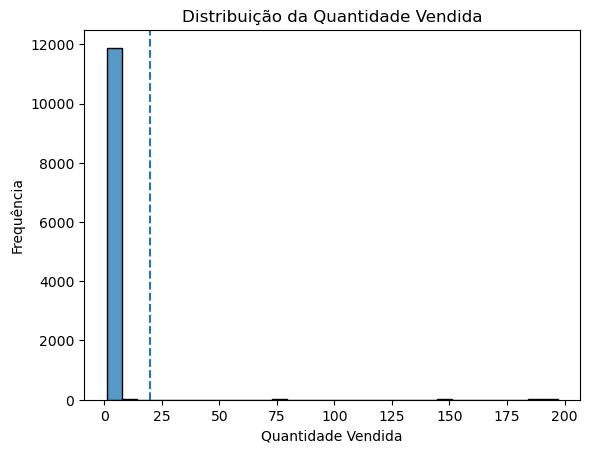

In [12]:
plt.figure()
sns.histplot(df["quantidade_vendida"], bins=30)
plt.axvline(20, linestyle="--")
plt.title("Distribuição da Quantidade Vendida")
plt.xlabel("Quantidade Vendida")
plt.ylabel("Frequência")
plt.show()

> O histograma evidencia uma distribuição assimétrica à direita, com uma cauda longa e presença de valores extremos de `quantidade_vendida`. Esses registros representam volumes operacionalmente improváveis para vendas unitárias e tendem a distorcer KPIs de volume e faturamento.

In [13]:
limite_qtd = 20
df["flag_excluir_qtd"] = df["quantidade_vendida"] > limite_qtd

df["flag_excluir_qtd"].value_counts()

flag_excluir_qtd
False    11896
True       104
Name: count, dtype: int64

> Com base no diagnóstico da distribuição e em critérios de plausibilidade operacional, foi definido um limiar máximo de unidades por item vendido. Registros acima desse limiar foram sinalizados para exclusão da base analítica principal, sendo preservados para fins de auditoria e análise de impacto da qualidade dos dados. Aproximadamente 0,9% dos registros foram afetados por esse critério, indicando impacto marginal sobre o volume total da base, mas potencialmente relevante sobre métricas agregadas.

In [14]:
df_base_analitica = df.loc[~df["flag_excluir_qtd"]].copy()
df_excluidos_qd = df.loc[df["flag_excluir_qtd"]].copy()

print(f"Tamanho base original: {len(df)}")
print(f"Tamanho base analítica: {len(df_base_analitica)}")
print(f"Registros excluídos por quantidade: {len(df_excluidos_qd)}")

Tamanho base original: 12000
Tamanho base analítica: 11896
Registros excluídos por quantidade: 104


> A partir desse ponto, as análises subsequentes utilizam a base analítica filtrada (`df_base_analitica`), enquanto os registros excluídos são preservados em um conjunto separado para fins de auditoria e avaliação de impacto da qualidade dos dados.

In [15]:
faturamento_antes = df["valor_total"].sum()
faturamento_depois = df_base_analitica["valor_total"].sum()

volume_antes = df["quantidade_vendida"].sum()
volume_depois = df_base_analitica["quantidade_vendida"].sum()

print(f"Impacto inicial no faturamento: {(faturamento_depois - faturamento_antes)/faturamento_antes:.2%}")
print(f"Impacto inicial no volume: {(volume_depois - volume_antes)/volume_antes:.2%}")

Impacto inicial no faturamento: -0.75%
Impacto inicial no volume: -27.66%


> Nesta etapa, o impacto é avaliado exclusivamente em função da exclusão de registros com quantidades operacionalmente implausíveis. O faturamento utilizado ainda corresponde ao valor informado na base original. Os impactos decorrentes da correção da regra de faturamento serão avaliados em etapas posteriores do pipeline de preparação dos dados.

## 3.5. Diagnóstico e Validação da Coluna `desconto`
Nesta etapa, a variável `desconto` é analisada quanto ao seu domínio de valores e plausibilidade em relação à regra de negócio. Valores extremos são identificados e avaliados, uma vez que descontos elevados podem indicar erros de escala ou inconsistências de registro que impactam diretamente o cálculo do faturamento.

### 3.5.1 Distribuição e domínio de `desconto`

In [16]:
df_base_analitica["desconto"].info()

<class 'pandas.Series'>
Index: 11896 entries, 0 to 11999
Series name: desconto
Non-Null Count  Dtype  
--------------  -----  
11896 non-null  float64
dtypes: float64(1)
memory usage: 185.9 KB


> A inspeção da estrutura da coluna indica que `desconto` encontra-se corretamente tipada e não apresenta valores ausentes relevantes.

In [17]:
df_base_analitica["desconto"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    11896.000000
mean         0.067567
std          0.070381
min          0.000000
50%          0.060000
90%          0.120000
95%          0.140000
99%          0.200000
max          0.900000
Name: desconto, dtype: float64

> A análise dos percentis indica que a maior parte dos registros apresenta descontos em um intervalo operacional esperado, enquanto uma pequena fração concentra valores significativamente mais elevados, caracterizando potenciais casos atípicos.

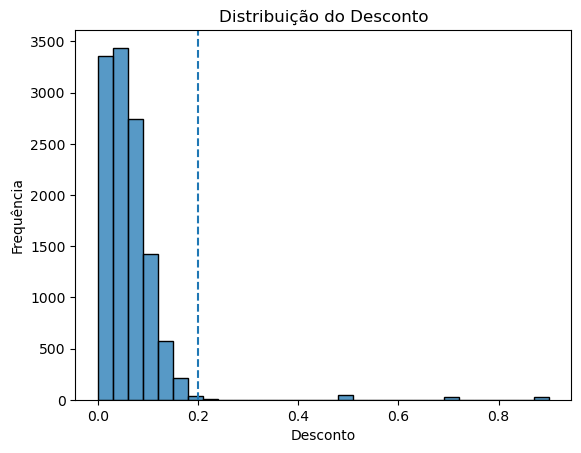

In [18]:
plt.figure()
sns.histplot(df_base_analitica["desconto"], bins=30)
plt.axvline(0.20, linestyle="--")
plt.title("Distribuição do Desconto")
plt.xlabel("Desconto")
plt.ylabel("Frequência")
plt.show()

> A visualização confirma uma distribuição assimétrica à direita, com poucos registros concentrando descontos elevados. O limiar destacado (≈ 20%) corresponde ao percentil 99, utilizado como referência para sinalização de valores extremos.

### 3.5.2 Sinalização de descontos extremos (governança)
Registros com valores de `desconto` acima do limiar de plausibilidade definido são sinalizados para auditoria e análise de impacto, sem exclusão automática nesta etapa.

In [19]:
limite_desconto = 0.20

df_base_analitica["flag_desconto_extremo"] = df_base_analitica["desconto"] > limite_desconto

df_base_analitica["flag_desconto_extremo"].value_counts()

flag_desconto_extremo
False    11782
True       114
Name: count, dtype: int64

> Aproximadamente 1% dos registros apresentam descontos acima do limiar de plausibilidade definido. Esses casos foram mantidos na base analítica, porém sinalizados para auditoria e avaliação de impacto no faturamento, evitando exclusões automáticas de possíveis promoções legítimas.

## 3.6. Validação da Regra de Negócio e Recálculo do Faturamento (`valor_total`)

Nesta etapa, o faturamento informado na base (`valor_total`) é validado em relação à regra de negócio definida (Preço Unitário × Quantidade Vendida × (1 – Desconto)). São identificadas divergências relevantes entre o valor informado e o valor esperado, permitindo avaliar a qualidade da informação financeira e definir a versão do faturamento a ser utilizada nas análises subsequentes.

### 3.6.1 Cálculo do valor total esperado (`valor_total_calc`)
O valor total esperado por venda é calculado a partir da regra de negócio definida, utilizando as variáveis previamente validadas (`preco_unitario`, `quantidade_vendida` e `desconto`).

In [20]:
df_base_analitica["valor_total_calc"] = (
    df_base_analitica["preco_unitario"] *
    df_base_analitica["quantidade_vendida"] *
    (1 - df_base_analitica["desconto"])
)

> O valor total esperado (`valor_total_calc`) é utilizado como referência para avaliar a consistência do faturamento informado na base original.

### 3.6.2 Diagnóstico das divergências entre valor informado e calculado
Nesta etapa, é quantificada a divergência entre o faturamento informado (`valor_total`) e o valor esperado pela regra de negócio (`valor_total_calc`), permitindo avaliar a magnitude e a frequência das inconsistências financeiras na base original.

In [21]:
df_base_analitica["erro_rel_valor"] = (
    (df_base_analitica["valor_total"] - df_base_analitica["valor_total_calc"]).abs() /
    df_base_analitica["valor_total_calc"]
)

In [22]:
df_base_analitica["erro_rel_valor"].describe(percentiles=[0.5, 0.9, 0.95, 0.99])

count    11896.000000
mean         0.174509
std          0.662886
min          0.000000
50%          0.000000
90%          0.400000
95%          0.400000
99%          2.464211
max         31.046667
Name: erro_rel_valor, dtype: float64

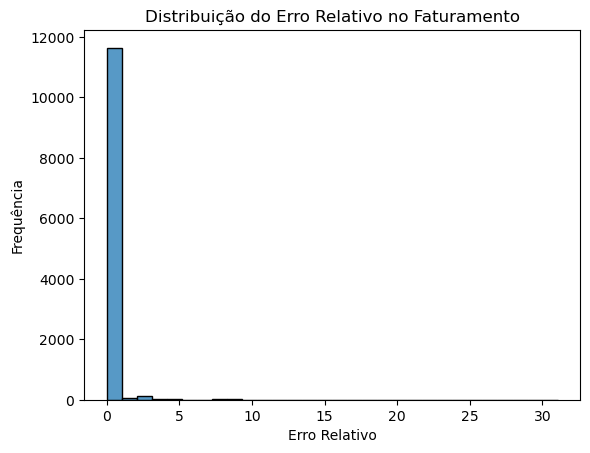

In [23]:
plt.figure()
sns.histplot(df_base_analitica["erro_rel_valor"], bins=30)
plt.title("Distribuição do Erro Relativo no Faturamento")
plt.xlabel("Erro Relativo")
plt.ylabel("Frequência")
plt.show()

> A análise do erro relativo evidencia que, embora parte da base apresente consistência com a regra de negócio, uma parcela significativa dos registros apresenta divergências relevantes no faturamento informado. Observam-se casos com erros superiores a 40% já nos percentis superiores e valores extremos de discrepância, caracterizando inconsistências financeiras estruturais na base original.  
>  
> Diante desse cenário, o valor recalculado (`valor_total_calc`) será adotado como métrica de referência para as análises financeiras subsequentes, garantindo aderência à regra de negócio e maior confiabilidade dos indicadores de faturamento.

## 3.7. Diagnóstico e Padronização da Coluna `categoria`
Nesta etapa, a coluna `categoria` é analisada quanto à presença de valores ausentes e consistência semântica em relação aos produtos. Registros com categoria não informada são tratados com base na relação entre produto e categoria observada na base, visando garantir consistência categórica nas análises subsequentes.

In [24]:
df_base_analitica["categoria"].isna().mean(), df_base_analitica["categoria"].value_counts(dropna=False).head(10)

(np.float64(0.0398453261600538),
 categoria
 Roupas         4323
 Eletrônicos    4258
 Educação       1468
 Livros         1373
 NaN             474
 Name: count, dtype: int64)

> A inspeção da coluna `categoria` evidencia a presença de valores ausentes, além de uma distribuição concentrada em um conjunto reduzido de categorias. Dada a relação funcional entre produto e categoria, é possível inferir a categoria ausente com base no produto correspondente.

In [25]:
map_prod_cat = (
    df_base_analitica
    .dropna(subset=["categoria"])
    .groupby("produto")["categoria"]
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
)

df_base_analitica["categoria"] = df_base_analitica["categoria"].fillna(
    df_base_analitica["produto"].map(map_prod_cat)
)

df_base_analitica["categoria"] = df_base_analitica["categoria"].fillna("Não Definida")

> As categorias ausentes foram imputadas com base no mapeamento produto → categoria mais frequente, explorando a relação funcional entre essas variáveis. Casos residuais sem inferência possível foram explicitamente categorizados como “Não Definida”, garantindo completude da variável para análises categóricas subsequentes.

In [26]:
df_base_analitica["categoria"].isna().mean(), df_base_analitica["categoria"].value_counts().head()

(np.float64(0.0),
 categoria
 Roupas         4492
 Eletrônicos    4445
 Educação       1537
 Livros         1422
 Name: count, dtype: int64)

> Após o tratamento, a coluna `categoria` não apresenta valores ausentes. A distribuição final das categorias reflete a consistência semântica entre produto e categoria, permitindo seu uso confiável em análises segmentadas por tipo de produto.

## 3.8. Diagnóstico e Padronização da Coluna `forma_pagamento`
Nesta etapa, a coluna `forma_pagamento` é analisada quanto à presença de valores ausentes e à consistência dos rótulos utilizados. O objetivo é garantir padronização dos métodos de pagamento, evitando fragmentação de categorias e viabilizando análises confiáveis por meio de pagamento.

In [27]:
df_base_analitica["forma_pagamento"].value_counts(dropna=False)

forma_pagamento
Cartão de Crédito    5261
Pix                  2659
Cartão de Débito     2290
Boleto               1208
NaN                   478
Name: count, dtype: int64

> A distribuição dos métodos de pagamento evidencia concentração em poucos meios (cartões e Pix), além da presença de registros sem forma de pagamento informada. Esses valores ausentes devem ser tratados para evitar perda de registros ou vieses em análises por meio de pagamento.

In [28]:
df_base_analitica["forma_pagamento"].isna().mean()

np.float64(0.040181573638197715)

> Aproximadamente uma fração relevante da base apresenta registros sem informação de forma de pagamento. Como não há uma relação funcional direta que permita inferência segura desse campo, os valores ausentes serão tratados de forma explícita, sem imputação semântica.

In [29]:
df_base_analitica["forma_pagamento"] = df_base_analitica["forma_pagamento"].fillna("Não informado")

In [30]:
df_base_analitica["forma_pagamento"].value_counts(dropna=False)

forma_pagamento
Cartão de Crédito    5261
Pix                  2659
Cartão de Débito     2290
Boleto               1208
Não informado         478
Name: count, dtype: int64

> Após o tratamento, a coluna `forma_pagamento` não apresenta valores ausentes. A distribuição final dos métodos de pagamento está padronizada, permitindo análises segmentadas por meio de pagamento sem perda de registros.

## 3.9. Ajuste da Coluna Localização
Nesta etapa, a coluna `localizacao` é analisada quanto à consistência dos rótulos de localidade. Diferentes representações para a mesma cidade são padronizadas, visando evitar fragmentação geográfica e garantir consistência nas análises por localidade.

In [31]:
df_base_analitica["localizacao"].value_counts(dropna=False)

localizacao
São Paulo         2800
Rio de Janeiro    2775
Belo Horizonte    1650
Curitiba          1262
Salvador           840
NaN                462
SP                 423
Sao Paulo          410
são paulo          388
curitiba           268
CTBA               258
salvador           186
SSA                174
Name: count, dtype: int64

> A inspeção da coluna `localizacao` evidencia fragmentação de rótulos para a mesma cidade, com variações de grafia, acentuação, abreviações e caixa (maiúsculas/minúsculas), além de valores ausentes. Essa fragmentação compromete análises geográficas e requer padronização dos rótulos de localidade.

In [32]:
map_localizacao = {
    "SP": "São Paulo",
    "Sao Paulo": "São Paulo",
    "são paulo": "São Paulo",
    "curitiba": "Curitiba",
    "CTBA": "Curitiba",
    "salvador": "Salvador",
    "SSA":"Salvador"
}
df_base_analitica["localizacao"] = df_base_analitica["localizacao"].replace(map_localizacao)

In [33]:
df_base_analitica["localizacao"] = df_base_analitica["localizacao"].fillna("Não informado")

In [34]:
df_base_analitica["localizacao"].value_counts().head(20)

localizacao
São Paulo         4021
Rio de Janeiro    2775
Curitiba          1788
Belo Horizonte    1650
Salvador          1200
Não informado      462
Name: count, dtype: int64

> Os valores da variável `localizacao` foram padronizados para nomes canônicos de cidades, consolidando variações de escrita, acentuação e abreviações. Registros com ausência de informação foram tratados com a categoria explícita “Não informado”, garantindo consistência nas análises geográficas e rastreabilidade das lacunas de dados.

---
# 4. Chave técnica (unicidade) + deduplicação
Nesta etapa, é definida uma chave técnica de unicidade para os registros de venda, dado que o identificador original (`id_venda`) não é único na base. A partir dessa chave, são identificados e tratados registros duplicados, distinguindo-se duplicatas perfeitas de possíveis conflitos de informação. O objetivo é garantir a unicidade lógica dos registros na base analítica final, evitando distorções em métricas e KPIs.

## 4.1. Criação da Chave Técnica

Como o identificador original de venda (`id_venda`) não é único na base, é definida uma chave técnica composta para representar a unidade lógica de análise no nível de item de venda. A chave é construída a partir da combinação das colunas `id_venda`, `produto` e `data_venda`, permitindo identificar registros duplicados e garantir unicidade operacional na base analítica.

In [35]:
df_base_analitica["pk_tecnica"] = (
    df_base_analitica["id_venda"].astype(str) + "_" +
    df_base_analitica["produto"].astype(str) + "_" +
    df_base_analitica["data_venda"].dt.strftime("%Y-%m-%d %H:%M:%S")
)

> A chave técnica (`pk_tecnica`) foi criada como identificador único operacional no nível de item de venda. Essa chave será utilizada como base para a identificação e o tratamento de registros duplicados na etapa subsequente.

## 4.2. Diagnóstico de Duplicação
Nesta etapa, é avaliado o grau de duplicação dos registros com base na chave técnica definida, quantificando a proporção de chaves não únicas e caracterizando o volume de registros duplicados presentes na base analítica.

In [37]:
n_total = len(df_base_analitica)
n_pk_unicos = df_base_analitica["pk_tecnica"].nunique()

print(f"Registros totais: {n_total}")
print(f"PKs técnicas únicas: {n_pk_unicos}")
print(f"Duplicatas: {n_total - n_pk_unicos} ({1 - n_pk_unicos/n_total:.2%})")

Registros totais: 11896
PKs técnicas únicas: 11227
Duplicatas: 669 (5.62%)


> O diagnóstico indica que aproximadamente 5,6% dos registros apresentam duplicação em relação à chave técnica definida. Esse volume é suficiente para impactar métricas agregadas e KPIs, justificando a aplicação de regras explícitas de deduplicação na base analítica.

In [38]:
dups = df_base_analitica[df_base_analitica.duplicated(subset=["pk_tecnica"], keep=False)]

dups.sort_values("pk_tecnica").head(10)

,id_venda,data_venda,produto,categoria,preco_unitario,quantidade_vendida,desconto,valor_total,localizacao,forma_pagamento,flag_excluir_qtd,flag_desconto_extremo,valor_total_calc,erro_rel_valor,pk_tecnica
7923,1001,2023-01-26 00:00:00.000000000,Livro G,Livros,60.0,1,0.05,57.0,Não informado,Pix,False,False,57.0,0.0,1001_Livro G_2023-01-26 00:00:00
3198,1001,2023-01-26 00:00:00.000000000,Livro G,Livros,60.0,1,0.05,57.0,Curitiba,Pix,False,False,57.0,0.0,1001_Livro G_2023-01-26 00:00:00
4029,1003,2023-01-24 11:39:20.773849232,Calça E,Roupas,120.0,6,0.02,705.6,Curitiba,Boleto,False,False,705.6,0.0,1003_Calça E_2023-01-24 11:39:20
6770,1003,2023-01-24 11:39:20.773849232,Calça E,Roupas,120.0,6,0.02,705.6,Curitiba,Boleto,False,False,705.6,0.0,1003_Calça E_2023-01-24 11:39:20
1385,1004,2022-12-07 17:29:01.160773849,Livro G,Livros,60.0,2,0.02,117.6,Salvador,Pix,False,False,117.6,0.0,1004_Livro G_2022-12-07 17:29:01
1011,1004,2022-12-07 17:29:01.160773849,Livro G,Livros,60.0,2,0.02,117.6,Salvador,Pix,False,False,117.6,0.0,1004_Livro G_2022-12-07 17:29:01
4010,1005,2023-01-01 23:18:41.547698465,Fone C,Eletrônicos,300.0,2,0.07,558.0,São Paulo,Cartão de Débito,False,False,558.0,0.0,1005_Fone C_2023-01-01 23:18:41
7477,1005,2023-01-01 23:18:41.547698465,Fone C,Eletrônicos,300.0,2,0.07,558.0,São Paulo,Cartão de Débito,False,False,558.0,0.0,1005_Fone C_2023-01-01 23:18:41
6176,1007,2023-01-25 10:58:02.321547698,Calça E,Roupas,120.0,2,0.09,218.4,Rio de Janeiro,Pix,False,False,218.4,0.0,1007_Calça E_2023-01-25 10:58:02
1333,1007,2023-01-25 10:58:02.321547698,Calça E,Roupas,120.0,2,0.09,218.4,Rio de Janeiro,Pix,False,False,218.4,0.0,1007_Calça E_2023-01-25 10:58:02


> Os registros com chaves técnicas duplicadas foram isolados para inspeção qualitativa. Essa etapa permite avaliar se as duplicatas são perfeitas (registros idênticos) ou se apresentam conflitos de informação que demandem regras específicas de resolução.

### 4.2.1 Verificar se são Duplicatas Perfeitas ou Conflitantes
Nesta etapa, as duplicatas são classificadas em duplicatas perfeitas (registros idênticos em todas as colunas críticas) e duplicatas com conflito (diferenças em campos relevantes), orientando a estratégia de deduplicação a ser adotada.

In [39]:
dups = df_base_analitica[df_base_analitica.duplicated(subset=["pk_tecnica"], keep=False)]

# Ver se as duplicatas são idênticas em colunas críticas
cols_criticas = ["preco_unitario", "quantidade_vendida", "desconto", "valor_total"]

duplicatas_perfeitas = (
    dups.groupby("pk_tecnica")[cols_criticas]
        .nunique()
        .eq(1)
        .all(axis=1)
)

duplicatas_perfeitas.value_counts()

True     596
False     44
Name: count, dtype: int64

In [40]:
pk_conflitantes = duplicatas_perfeitas[~duplicatas_perfeitas].index

dups.loc[dups["pk_tecnica"].isin(pk_conflitantes)] \
    .sort_values("pk_tecnica") \
    .head(10)[["pk_tecnica", "preco_unitario", "quantidade_vendida", "desconto", "valor_total", "valor_total_calc"]]

,pk_tecnica,preco_unitario,quantidade_vendida,desconto,valor_total,valor_total_calc
2035,1014_Fone C_2023-01-15 03:45:45,300.0,3,0.04,700.408729,864.0
10315,1014_Fone C_2023-01-15 03:45:45,300.0,3,0.04,864.000000,864.0
6587,1021_Tênis F_2023-01-30 20:33:27,250.0,1,0.13,176.069640,217.5
48,1021_Tênis F_2023-01-30 20:33:27,250.0,1,0.13,217.500000,217.5
5533,1030_Camisa D_2023-01-25 01:00:31,80.0,2,0.03,193.742646,155.2
5741,1030_Camisa D_2023-01-25 01:00:31,80.0,2,0.03,155.200000,155.2
4425,1154_Fone C_2023-02-20 03:39:59,300.0,3,0.02,815.750453,882.0
6609,1154_Fone C_2023-02-20 03:39:59,300.0,3,0.02,882.000000,882.0
5050,1207_Curso Online H_2023-02-15 00:32:39,500.0,3,0.03,1455.000000,1455.0
7695,1207_Curso Online H_2023-02-15 00:32:39,500.0,3,0.03,1829.229890,1455.0


> A inspeção qualitativa das duplicatas conflitantes evidencia divergências em campos críticos de valor e desconto para a mesma chave técnica, caracterizando inconsistências de origem que não podem ser resolvidas por simples deduplicação. Esses casos demandam uma regra explícita de priorização ou exclusão controlada na construção da base analítica final.

## 4.3. Deduplicação

Com base na classificação das duplicatas, são adotadas regras distintas de tratamento para duplicatas perfeitas e duplicatas com conflito de informação. Duplicatas perfeitas são removidas por representarem replicações idênticas do mesmo evento de venda. Já os casos conflitantes são segregados para auditoria, uma vez que apresentam inconsistências de origem que não podem ser resolvidas de forma automática sem risco de distorção analítica.

In [41]:
df_base_analitica["erro_rel_valor"] = (
    (df_base_analitica["valor_total"] - df_base_analitica["valor_total_calc"]).abs() /
    df_base_analitica["valor_total_calc"]
)

idx_melhor = df_base_analitica.groupby("pk_tecnica")["erro_rel_valor"].idxmin()
df_base_analitica_dedup = df_base_analitica.loc[idx_melhor].copy()

> Para resolver duplicatas conflitantes, foi adotado um critério de qualidade baseado na aderência à regra de negócio do faturamento. Para cada chave técnica, manteve-se o registro com menor erro relativo entre o valor informado e o valor recalculado (`valor_total_calc`), priorizando o registro mais consistente com a regra de negócio definida.

In [42]:
print("Antes:", len(df_base_analitica))
print("Depois:", len(df_base_analitica_dedup))
print("PKs únicas depois:", df_base_analitica_dedup["pk_tecnica"].nunique())

Antes: 11896
Depois: 11227
PKs únicas depois: 11227


> A deduplicação resultou na remoção de aproximadamente 5,6% dos registros da base analítica, garantindo unicidade em relação à chave técnica definida. A base final consolidada (`df_base_analitica_dedup`) passa a representar cada evento lógico de venda por um único registro, eliminando distorções em métricas e KPIs decorrentes de duplicações na ingestão dos dados.

# 5. Base Final e Próximos Passos

A partir do pipeline de limpeza e preparação dos dados, foi construída uma base analítica consistente, com:
- Tipagem correta das variáveis;
- Padronização de campos categóricos;
- Validação e recálculo do faturamento com base na regra de negócio;
- Remoção e resolução de registros duplicados com base em critérios de qualidade.

A base final processada encontra-se pronta para análises exploratórias, construção de KPIs e eventuais modelos analíticos nas próximas etapas do projeto.

In [43]:
df_base_final = df_base_analitica_dedup.copy()
df_base_final.to_csv("../data/processed/ecommerce_base_final.csv", index=False)

> A base analítica final, após todas as etapas de limpeza, validação e deduplicação, é exportada para o diretório `data/processed/` no formato CSV. Este artefato constitui a versão oficial dos dados a ser utilizada nas análises exploratórias, construção de KPIs e etapas analíticas subsequentes do projeto.